# Рекомендательная система для интернет-магазина
## Учебный проект по Data Science

**Цель:** построить рекомендательную систему которая предсказывает топ-3 товара для покупки.

**Данные:** RetailRocket — события пользователей интернет-магазина (просмотры, корзина, покупки).

**Архитектура:** двухэтапная схема — Candidate Generation + LightGBM Ranking.

**Метрика:** Precision@3 на валидационной выборке.

---

### Порядок выполнения ноутбука

1. EDA — исследование данных
2. Temporal split — разбивка по времени
3. Feature Engineering — генерация признаков
4. Candidate Generation — отбор кандидатов
5. Модели — ALS, LightGBM, XGBoost
6. Сохранение артефактов для сервиса

---
## 1. Подготовка окружения

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
from itertools import combinations
from collections import defaultdict
import gc

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Пути к данным
# CSV файлы лежат в той же папке что и ноутбук
file_path = ""
save_path = "processed/"
os.makedirs(save_path, exist_ok=True)

print('Библиотеки загружены ✅')

Библиотеки загружены ✅


---
## 2. Исследование данных (EDA)

### 2.1 Events

In [2]:
events_raw = pd.read_csv(file_path + 'events.csv')
events = events_raw.copy()
print(f'Строк: {len(events):,}')
events.head()

Строк: 2,756,101


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [3]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 116.1 MB


In [4]:
print('Пропуски:')
print(events.isnull().sum())
print(f'\nДубликаты строк: {events.duplicated().sum()}')
print(f'\nУникальных пользователей: {events["visitorid"].nunique():,}')
print(f'Уникальных товаров:       {events["itemid"].nunique():,}')
print(f'Уникальных транзакций:    {events["transactionid"].nunique():,}')

Пропуски:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64



Дубликаты строк: 460

Уникальных пользователей: 1,407,580
Уникальных товаров:       235,061


Уникальных транзакций:    17,672


In [5]:
# Удаляем точные дубликаты (459 строк — артефакт данных)
events = events.drop_duplicates()
print(f'Строк после удаления дубликатов: {len(events):,}')

Строк после удаления дубликатов: 2,755,641


In [6]:
# Конвертация timestamp из миллисекунд в datetime
events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
print(f'Период данных: {events["datetime"].min()} → {events["datetime"].max()}')
print(f'Длительность: {(events["datetime"].max() - events["datetime"].min()).days} дней')

Период данных: 2015-05-03 03:00:04.384000 → 2015-09-18 02:59:47.788000
Длительность: 137 дней


event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64

Доли (%): event
view           96.68
addtocart       2.50
transaction     0.81
Name: count, dtype: float64


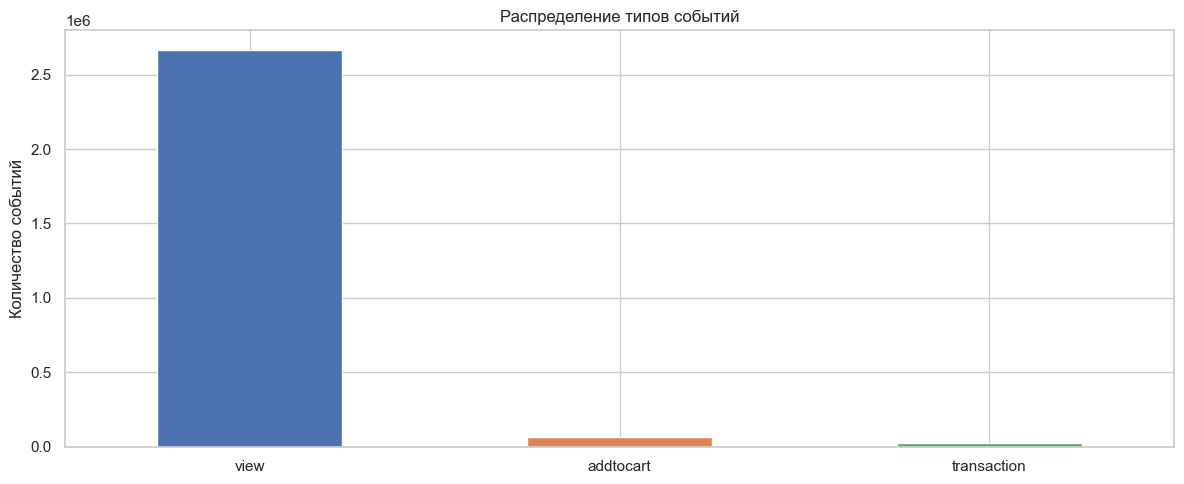

In [7]:
# Распределение типов событий
event_counts = events['event'].value_counts()
print(event_counts)
print('\nДоли (%):', (event_counts / len(events) * 100).round(2))

event_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Распределение типов событий')
plt.xlabel('')
plt.ylabel('Количество событий')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# Воронка: view → addtocart → transaction
funnel = {
    'view':        events[events['event'] == 'view']['visitorid'].nunique(),
    'addtocart':   events[events['event'] == 'addtocart']['visitorid'].nunique(),
    'transaction': events[events['event'] == 'transaction']['visitorid'].nunique(),
}
funnel_df = pd.DataFrame.from_dict(funnel, orient='index', columns=['users'])
funnel_df['conv_from_view_%'] = (funnel_df['users'] / funnel_df.loc['view', 'users'] * 100).round(2)
print(funnel_df)

               users  conv_from_view_%
view         1404179            100.00
addtocart      37722              2.69
transaction    11719              0.83


In [9]:
# Активность пользователей
user_activity = events.groupby('visitorid').size().rename('event_count')
print(user_activity.describe())

count    1.407580e+06
mean     1.957715e+00
std      1.257981e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
Name: event_count, dtype: float64


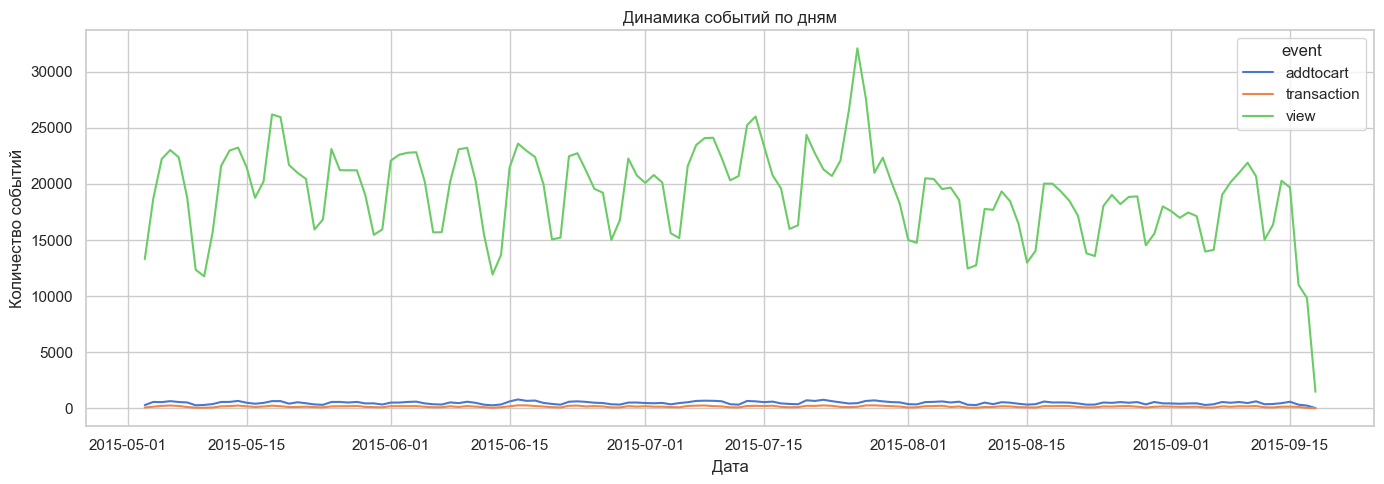

In [10]:
# Активность по времени
events['date'] = events['datetime'].dt.date
daily = events.groupby(['date', 'event']).size().unstack(fill_value=0)
daily.plot(figsize=(14, 5), title='Динамика событий по дням')
plt.xlabel('Дата')
plt.ylabel('Количество событий')
plt.tight_layout()
plt.show()

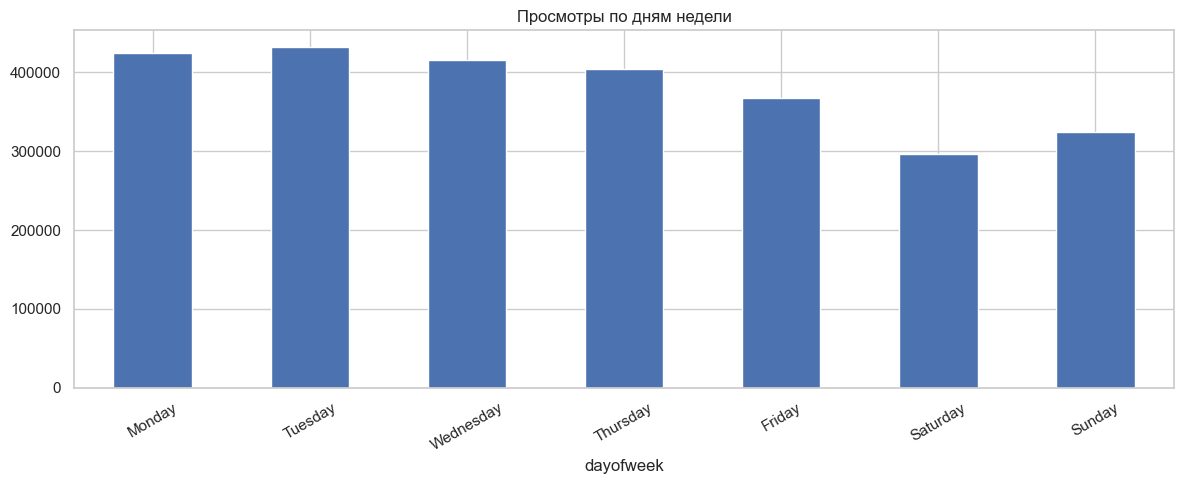

In [11]:
# Недельная сезонность
events['dayofweek'] = events['datetime'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = events[events['event'] == 'view'].groupby('dayofweek').size().reindex(dow_order)
dow_counts.plot(kind='bar', title='Просмотры по дням недели', color='#4C72B0')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Выводы по events:**

- Период данных: 2015-05-03 — 2015-09-18 (137 дней)
- После удаления дубликатов: **2 755 641 строк**
- Уникальных пользователей: 1 407 580, товаров: 235 061
- Воронка: view → addtocart: 2.69%, view → transaction: 0.83% — конверсия очень низкая
- Медиана событий на пользователя: 1 — большинство зашли один раз (cold start)
- Выраженная недельная сезонность: выходные на ~25% ниже будних → temporal split по понедельникам

### 2.2 Item properties

In [12]:
item_properties_part1 = pd.read_csv(file_path + 'item_properties_part1.csv')
item_properties_part2 = pd.read_csv(file_path + 'item_properties_part2.csv')
properties = pd.concat([item_properties_part1, item_properties_part2], ignore_index=True)
print(f'properties: {properties.shape}')
properties.head()

properties: (20275902, 4)


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [13]:
print(f'Дубликаты: {properties.duplicated().sum():,}')
print(f'Уникальных товаров:  {properties["itemid"].nunique():,}')
print(f'Уникальных свойств: {properties["property"].nunique():,}')
print('\nТоп свойств:')
print(properties['property'].value_counts().head(10))

Дубликаты: 0


Уникальных товаров:  417,053


Уникальных свойств: 1,104

Топ свойств:


property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
Name: count, dtype: int64


In [14]:
# Значения available
print('Значения available:')
print(properties[properties['property'] == 'available']['value'].value_counts())

# Сколько товаров меняли категорию
cat_changes = (properties[properties['property'] == 'categoryid']
               .groupby('itemid')['value'].nunique())
print(f'\nТоваров которые меняли категорию: {(cat_changes > 1).sum():,}')

Значения available:


value
0    863086
1    640553
Name: count, dtype: int64



Товаров которые меняли категорию: 23,352


**Выводы по item_properties:**

- Объединены part1 + part2: **20 275 902 строк**, дубликатов нет
- 1 104 свойства, почти все захешированы — семантику не восстановить
- Нехешированные: `categoryid` и `available` (бинарный 0/1)
- 21% активных товаров из events не имеют записей в properties — категория для них недоступна

### 2.3 Category tree

In [15]:
category = pd.read_csv(file_path + 'category_tree.csv')
print(f'Категорий: {category["categoryid"].nunique():,}')
print(f'Корневых (parentid == NaN): {category["parentid"].isnull().sum()}')
category.head()

Категорий: 1,669
Корневых (parentid == NaN): 25


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [16]:
# Глубина дерева категорий
parent_map = category.dropna(subset=['parentid']).set_index('categoryid')['parentid'].astype(int).to_dict()

def get_depth(cat_id, parent_map, memo={}):
    if cat_id in memo:
        return memo[cat_id]
    if cat_id not in parent_map:
        memo[cat_id] = 0
        return 0
    depth = 1 + get_depth(parent_map[cat_id], parent_map, memo)
    memo[cat_id] = depth
    return depth

def get_parent(cat_id, parent_map):
    return parent_map.get(cat_id, None)

category['depth']     = category['categoryid'].apply(lambda x: get_depth(x, parent_map))
category['parent_id'] = category['categoryid'].apply(lambda x: get_parent(x, parent_map))
print(category['depth'].value_counts().sort_index())

depth
0     25
1    174
2    702
3    665
4     90
5     13
Name: count, dtype: int64


**Выводы по category_tree:**

- 1 669 категорий, 25 корневых, глубина до 5 уровней
- Дерево целостное: все parentid ссылаются на существующие categoryid
- Используем depth и parent_id как признаки для модели

---
## 3. Temporal split

Разбиваем данные по времени на три выборки. Границы выставлены по **понедельникам** чтобы не разрывать недельный цикл сезонности. Первая неполная неделя (до 2015-05-03, 13К событий) отрезана.

Все признаки будем считать **только по train** — это исключает data leakage.

In [17]:
# Смотрим недельное распределение событий
events['week'] = events['datetime'].dt.to_period('W')
weekly = events.groupby('week').size()
print(weekly)

week
2015-04-27/2015-05-03     13682
2015-05-04/2015-05-10    133760
2015-05-11/2015-05-17    148840
2015-05-18/2015-05-24    152500
2015-05-25/2015-05-31    141802
2015-06-01/2015-06-07    146426
2015-06-08/2015-06-14    131827
2015-06-15/2015-06-21    145957
2015-06-22/2015-06-28    141677
2015-06-29/2015-07-05    139211
2015-07-06/2015-07-12    161825
2015-07-13/2015-07-19    152214
2015-07-20/2015-07-26    175392
2015-07-27/2015-08-02    144304
2015-08-03/2015-08-09    128529
2015-08-10/2015-08-16    120730
2015-08-17/2015-08-23    126889
2015-08-24/2015-08-30    127794
2015-08-31/2015-09-06    119031
2015-09-07/2015-09-13    138773
2015-09-14/2015-09-20     64478
Freq: W-SUN, dtype: int64


In [18]:
train_start = '2015-05-04'
train_end   = '2015-08-16'
val_start   = '2015-08-17'
val_end     = '2015-08-30'
test_start  = '2015-08-31'
test_end    = '2015-09-18'

train = events[(events['datetime'] >= train_start) & (events['datetime'] <= train_end)].copy()
val   = events[(events['datetime'] >= val_start)   & (events['datetime'] <= val_end)].copy()
test  = events[(events['datetime'] >= test_start)  & (events['datetime'] <= test_end)].copy()

total = len(train) + len(val) + len(test)
print(f'Train: {len(train):,} ({len(train)/total*100:.1f}%)  {train["datetime"].min().date()} — {train["datetime"].max().date()}')
print(f'Val:   {len(val):,} ({len(val)/total*100:.1f}%)  {val["datetime"].min().date()} — {val["datetime"].max().date()}')
print(f'Test:  {len(test):,} ({len(test)/total*100:.1f}%)  {test["datetime"].min().date()} — {test["datetime"].max().date()}')

for name, df in [('Train', train), ('Val', val), ('Test', test)]:
    n_transactions = (df['event'] == 'transaction').sum()
    n_users = df['visitorid'].nunique()
    print(f'{name}: {n_transactions:,} транзакций, {n_users:,} уникальных пользователей')

Train: 2,150,507 (79.4%)  2015-05-04 — 2015-08-15
Val:   238,406 (8.8%)  2015-08-17 — 2015-08-29
Test:  320,754 (11.8%)  2015-08-31 — 2015-09-17
Train: 17,464 транзакций, 1,095,990 уникальных пользователей
Val: 2,142 транзакций, 135,839 уникальных пользователей
Test: 2,529 транзакций, 183,346 уникальных пользователей


In [19]:
# Сохраняем выборки
train.to_parquet(save_path + 'train.parquet')
val.to_parquet(save_path + 'val.parquet')
test.to_parquet(save_path + 'test.parquet')
print('Сохранено ✅')

Сохранено ✅


**Важное наблюдение:** в val и test много пользователей которых нет в train (135К и 183К против 1М в train). Это реалистично — 84% покупателей в val новые пользователи. Cold start будет значимой проблемой и это нужно учесть при построении модели.

---
## 4. Feature Engineering

Генерируем три типа признаков. Все считаются **только по train** — данные из val и test не используются.

| Тип | Описание |
|-----|---------|
| Item features | Популярность, категория, time-decay |
| User features | Активность пользователя, конверсия |
| User-item features | История взаимодействий пары пользователь–товар |

### 4.1 Признаки товаров

In [20]:
# Свойства товаров берём только до конца train — исключаем leakage
train_end_ts = pd.Timestamp(train_end).value // 10**6
props_train = properties[properties['timestamp'] <= train_end_ts]

# Категория товара — последнее значение по timestamp
item_category = (
    props_train[props_train['property'] == 'categoryid']
    .sort_values('timestamp')
    .groupby('itemid')['value']
    .last()
    .reset_index()
    .rename(columns={'value': 'categoryid'})
)
item_category['categoryid'] = item_category['categoryid'].astype(int)

# Статус наличия — последнее значение по timestamp
item_available = (
    props_train[props_train['property'] == 'available']
    .sort_values('timestamp')
    .groupby('itemid')['value']
    .last()
    .reset_index()
    .rename(columns={'value': 'available'})
)
item_available['available'] = item_available['available'].astype(int)

print(f'Товаров с категорией: {len(item_category):,}')
print(f'Товаров со статусом available: {len(item_available):,}')

Товаров с категорией: 408,922
Товаров со статусом available: 410,641


In [21]:
# Popularity-факторы из train
item_views     = train[train['event'] == 'view'].groupby('itemid').size().reset_index(name='n_views')
item_carts     = train[train['event'] == 'addtocart'].groupby('itemid').size().reset_index(name='n_carts')
item_purchases = train[train['event'] == 'transaction'].groupby('itemid').size().reset_index(name='n_purchases')

item_features = (
    item_views
    .merge(item_carts,     on='itemid', how='left')
    .merge(item_purchases, on='itemid', how='left')
)
item_features[['n_carts', 'n_purchases']] = item_features[['n_carts', 'n_purchases']].fillna(0).astype(int)
item_features['cart_to_view_ratio'] = (item_features['n_carts'] / item_features['n_views']).round(4)

print(f'Товаров с popularity-факторами: {len(item_features):,}')

Товаров с popularity-факторами: 210,510


In [22]:
# Time-decay — популярность за последние 7 и 30 дней train
train_end_dt = pd.Timestamp(train_end)
last_7_days  = train_end_dt - pd.Timedelta(days=7)
last_30_days = train_end_dt - pd.Timedelta(days=30)

item_views_7  = train[(train['event'] == 'view') & (train['datetime'] >= last_7_days)].groupby('itemid').size().reset_index(name='n_views_7d')
item_views_30 = train[(train['event'] == 'view') & (train['datetime'] >= last_30_days)].groupby('itemid').size().reset_index(name='n_views_30d')
item_carts_7  = train[(train['event'] == 'addtocart') & (train['datetime'] >= last_7_days)].groupby('itemid').size().reset_index(name='n_carts_7d')

# Размер категории
category_size = item_category.groupby('categoryid').size().reset_index(name='category_size')

# Итоговая таблица item_features
item_features = (
    item_features
    .merge(item_category,  on='itemid',      how='left')
    .merge(item_available, on='itemid',      how='left')
    .merge(category[['categoryid', 'depth', 'parent_id']], on='categoryid', how='left')
    .merge(category_size,  on='categoryid',  how='left')
    .merge(item_views_7,   on='itemid',      how='left')
    .merge(item_views_30,  on='itemid',      how='left')
    .merge(item_carts_7,   on='itemid',      how='left')
)
item_features[['n_views_7d', 'n_views_30d', 'n_carts_7d']] = (
    item_features[['n_views_7d', 'n_views_30d', 'n_carts_7d']].fillna(0).astype(int)
)

print(f'item_features: {item_features.shape}')
print('\nПропуски:')
print(item_features.isnull().sum())

item_features: (210510, 13)

Пропуски:
itemid                    0
n_views                   0
n_carts                   0
n_purchases               0
cart_to_view_ratio        0
categoryid            45148
available             44314
depth                 45148
parent_id             45149
category_size         45148
n_views_7d                0
n_views_30d               0
n_carts_7d                0
dtype: int64


In [23]:
item_features.to_parquet(save_path + 'item_features.parquet')
print('item_features сохранён ✅')

item_features сохранён ✅


**Итог:** 210 510 товаров, 13 признаков. ~21% товаров без категории (нет в item_properties) — для них категориальные признаки будут `-1`.

### 4.2 Признаки пользователей

In [24]:
user_views     = train[train['event'] == 'view'].groupby('visitorid').size().reset_index(name='user_total_views')
user_purchases = train[train['event'] == 'transaction'].groupby('visitorid').size().reset_index(name='user_total_purchases')

user_features = user_views.merge(user_purchases, on='visitorid', how='left')
user_features['user_total_purchases'] = user_features['user_total_purchases'].fillna(0).astype(int)
user_features['user_conversion_rate'] = (user_features['user_total_purchases'] / user_features['user_total_views']).round(4)

# Любимая категория — категория с наибольшим числом просмотров
train_with_cat = train[train['event'] == 'view'].merge(item_category[['itemid', 'categoryid']], on='itemid', how='left')
user_fav_category = (
    train_with_cat.dropna(subset=['categoryid'])
    .groupby(['visitorid', 'categoryid']).size()
    .reset_index(name='cat_views')
    .sort_values('cat_views', ascending=False)
    .groupby('visitorid').first()
    .reset_index()[['visitorid', 'categoryid']]
    .rename(columns={'categoryid': 'user_fav_category'})
)
user_features = user_features.merge(user_fav_category, on='visitorid', how='left')

print(f'user_features: {user_features.shape}')
user_features.head()

user_features: (1093540, 5)


,visitorid,user_total_views,user_total_purchases,user_conversion_rate,user_fav_category
0,1,1,0,0.0,1192.0
1,2,8,0,0.0,299.0
2,3,1,0,0.0,1171.0
3,5,1,0,0.0,646.0
4,7,3,0,0.0,1114.0


In [25]:
user_features.to_parquet(save_path + 'user_features.parquet')
print('user_features сохранён ✅')

user_features сохранён ✅


### 4.3 Признаки пары пользователь–товар

In [26]:
event_rank = {'view': 1, 'addtocart': 2, 'transaction': 3}
train['event_rank'] = train['event'].map(event_rank)

user_item_views     = train[train['event'] == 'view'].groupby(['visitorid', 'itemid']).size().reset_index(name='ui_n_views')
user_item_carts     = train[train['event'] == 'addtocart'].groupby(['visitorid', 'itemid']).size().reset_index(name='ui_n_carts')
user_item_purchases = train[train['event'] == 'transaction'].groupby(['visitorid', 'itemid']).size().reset_index(name='ui_n_purchases')
user_item_max_event = train.groupby(['visitorid', 'itemid'])['event_rank'].max().reset_index(name='ui_max_event')

user_item_features = (
    user_item_views
    .merge(user_item_carts,     on=['visitorid', 'itemid'], how='left')
    .merge(user_item_purchases, on=['visitorid', 'itemid'], how='left')
    .merge(user_item_max_event, on=['visitorid', 'itemid'], how='left')
)
user_item_features[['ui_n_carts', 'ui_n_purchases']] = (
    user_item_features[['ui_n_carts', 'ui_n_purchases']].fillna(0).astype(int)
)

print(f'user_item_features: {user_item_features.shape}')
user_item_features.head()

user_item_features: (1661231, 6)


,visitorid,itemid,ui_n_views,ui_n_carts,ui_n_purchases,ui_max_event
0,1,72028,1,0,0,1
1,2,216305,2,0,0,1
2,2,259884,1,0,0,1
3,2,325215,3,0,0,1
4,2,342816,2,0,0,1


In [27]:
user_item_features.to_parquet(save_path + 'user_item_features.parquet')
print('user_item_features сохранён ✅')

user_item_features сохранён ✅


---
## 5. Candidate Generation

Вместо того чтобы ранжировать все 235 000 товаров для каждого пользователя, сначала отбираем топ-100 кандидатов. Это делает систему быстрой.

Два источника кандидатов:
1. **Popularity baseline** — топ-100 самых популярных товаров (работает для всех, включая cold start)
2. **Item-based CF** — товары похожие на те что пользователь уже смотрел

### 5.1 Popularity baseline

In [28]:
N_CANDIDATES = 100

popularity = (
    train.groupby('itemid')
    .agg(
        n_purchases=('event', lambda x: (x == 'transaction').sum()),
        n_views=('event', lambda x: (x == 'view').sum())
    )
    .reset_index()
    .sort_values(['n_purchases', 'n_views'], ascending=False)
)

# Только доступные товары
available_items = set(item_features[item_features['available'] == 1]['itemid'].unique())
top_items = (
    popularity[popularity['itemid'].isin(available_items)]
    .head(N_CANDIDATES)['itemid']
    .tolist()
)

print(f'Топ-{N_CANDIDATES} кандидатов (только available=1): {len(top_items)}')
print(f'Покупок у топ-1 товара: {popularity.iloc[0]["n_purchases"]}')
print(f'Покупок у топ-100 товара: {popularity.iloc[99]["n_purchases"]}')

Топ-100 кандидатов (только available=1): 100
Покупок у топ-1 товара: 90
Покупок у топ-100 товара: 9


In [29]:
popularity.to_parquet(save_path + 'popularity.parquet')
print('popularity сохранён ✅')

popularity сохранён ✅


### 5.2 Item-based CF (co-occurrence)

Находим товары которые часто смотрят вместе в рамках одной сессии. Сессия — группа событий пользователя с перерывом не более 30 минут. Ограничение 10 товаров в сессии защищает от аномально длинных сессий которые исказили бы матрицу похожести.

In [30]:
# Определяем сессии
train_sorted = train.sort_values(['visitorid', 'timestamp'])
train_sorted['prev_timestamp'] = train_sorted.groupby('visitorid')['timestamp'].shift(1)
train_sorted['time_diff'] = train_sorted['timestamp'] - train_sorted['prev_timestamp']
train_sorted['new_session'] = (
    (train_sorted['time_diff'] > 30 * 60 * 1000) |
    (train_sorted['time_diff'].isna())
)
train_sorted['session_id'] = train_sorted.groupby('visitorid')['new_session'].cumsum()
train_sorted['session_id'] = train_sorted['visitorid'].astype(str) + '_' + train_sorted['session_id'].astype(str)

print(f'Уникальных сессий: {train_sorted["session_id"].nunique():,}')
print(f'Среднее событий в сессии: {train_sorted.groupby("session_id").size().mean():.1f}')

Уникальных сессий: 1,361,198


Среднее событий в сессии: 1.6


In [31]:
# Co-occurrence пар товаров в сессиях
session_items = (
    train_sorted[train_sorted['event'] == 'view']
    .groupby('session_id')['itemid']
    .apply(list)
    .reset_index()
)
session_items = session_items[session_items['itemid'].apply(len) >= 2]
print(f'Сессий с 2+ товарами: {len(session_items):,}')

cooccurrence = defaultdict(int)
for items in session_items['itemid']:
    items = items[:10]  # ограничение длины сессии
    for item_a, item_b in combinations(set(items), 2):
        cooccurrence[(item_a, item_b)] += 1
        cooccurrence[(item_b, item_a)] += 1

cooccurrence_df = pd.DataFrame([
    {'item_a': k[0], 'item_b': k[1], 'cooc_count': v}
    for k, v in cooccurrence.items()
]).sort_values('cooc_count', ascending=False)

# Топ-20 похожих для каждого товара
TOP_SIMILAR = 20
item_similar = (
    cooccurrence_df
    .sort_values('cooc_count', ascending=False)
    .groupby('item_a')
    .head(TOP_SIMILAR)
    .reset_index(drop=True)
)

print(f'Товаров с похожими: {item_similar["item_a"].nunique():,}')
print(f'Среднее похожих на товар: {item_similar.groupby("item_a").size().mean():.1f}')

Сессий с 2+ товарами: 287,263


Товаров с похожими: 101,433
Среднее похожих на товар: 7.6


In [32]:
item_similar.to_parquet(save_path + 'item_similar.parquet')
print('item_similar сохранён ✅')

item_similar сохранён ✅


**Наблюдение:** только 48% товаров имеют co-occurrence сигнал — большинство сессий слишком короткие (медиана = 1 событие). Для остальных товаров и cold start пользователей используется popularity baseline.

### 5.3 Объединение кандидатов

In [33]:
val_users = val['visitorid'].unique()
print(f'Пользователей в val: {len(val_users):,}')

# Popularity кандидаты для всех пользователей val
pop_df = pd.DataFrame([
    {'visitorid': user, 'itemid': item, 'source': 'popularity'}
    for user in val_users
    for item in top_items
])
print(f'Popularity кандидатов: {len(pop_df):,}')

# CF кандидаты — на основе истории просмотров в train
user_views_train = (
    train[train['event'] == 'view']
    .groupby('visitorid')['itemid']
    .apply(list)
    .reset_index()
)

cf_candidates = []
for _, row in user_views_train[user_views_train['visitorid'].isin(val_users)].iterrows():
    user = row['visitorid']
    viewed_items = set(row['itemid'])
    similar = (
        item_similar[item_similar['item_a'].isin(viewed_items)]
        .groupby('item_b')['cooc_count'].sum()
        .reset_index()
        .sort_values('cooc_count', ascending=False)
        .head(100)
    )
    for item in similar['item_b']:
        if item not in viewed_items and item in available_items:
            cf_candidates.append({'visitorid': user, 'itemid': item, 'source': 'cf'})

cf_df = pd.DataFrame(cf_candidates)
print(f'CF кандидатов: {len(cf_df):,}')

candidates = (
    pd.concat([pop_df, cf_df], ignore_index=True)
    .drop_duplicates(subset=['visitorid', 'itemid'])
)
print(f'Итого уникальных кандидатов: {len(candidates):,}')
print(f'Среднее кандидатов на пользователя: {candidates.groupby("visitorid").size().mean():.1f}')

Пользователей в val: 135,839


Popularity кандидатов: 13,583,900


CF кандидатов: 182,538


Итого уникальных кандидатов: 13,758,759


Среднее кандидатов на пользователя: 101.3


In [34]:
# Добавляем таргет — купил ли пользователь товар в val
val_purchases = (
    val[val['event'] == 'transaction']
    .groupby(['visitorid', 'itemid'])
    .size()
    .reset_index(name='purchased')
)
val_purchases['purchased'] = 1

candidates = candidates.merge(val_purchases, on=['visitorid', 'itemid'], how='left')
candidates['purchased'] = candidates['purchased'].fillna(0).astype(int)

print(f'Положительных примеров (покупки): {candidates["purchased"].sum():,}')
print(f'Отрицательных примеров: {(candidates["purchased"] == 0).sum():,}')
print(f'Дисбаланс классов: 1:{(candidates["purchased"] == 0).sum() // candidates["purchased"].sum():,}')

# Проверяем покрытие
val_purchase_users = set(val_purchases['visitorid'].unique())
candidates_users   = set(candidates['visitorid'].unique())
covered = len(val_purchase_users & candidates_users)
print(f'\nПокупателей в val покрыто кандидатами: {covered}/{len(val_purchase_users)} ({covered/len(val_purchase_users)*100:.1f}%)')

Положительных примеров (покупки): 173
Отрицательных примеров: 13,758,586
Дисбаланс классов: 1:79,529



Покупателей в val покрыто кандидатами: 1156/1156 (100.0%)


In [35]:
candidates.to_parquet(save_path + 'candidates.parquet')
print('candidates сохранён ✅')

candidates сохранён ✅


**Ключевое наблюдение:** дисбаланс классов 1:85 000 — одна покупка на 85 000 взаимодействий. Это критично для обучения: без специальной обработки модель будет предсказывать всё как 0 и получать 99.99% accuracy при нулевой пользе. Решение — negative sampling и `scale_pos_weight`.

---
## 6. Модели

Сравниваем три подхода:
1. **ALS** — матричная факторизация (collaborative filtering baseline)
2. **LightGBM** — градиентный бустинг на признаках
3. **XGBoost** — альтернативный градиентный бустинг

Метрика оценки: **Precision@3** на val выборке.

### 6.1 ALS (Alternating Least Squares)

Матричная факторизация на implicit feedback. Попробуем как baseline — стандартный подход для рекомендательных систем.

Взвешенные взаимодействия: view=1, addtocart=3, transaction=5. Для cold start пользователей — fallback на popularity baseline.

In [36]:
!pip install implicit -q
import implicit
from scipy.sparse import csr_matrix

In [37]:
# Взвешенная матрица взаимодействий — только по train
event_weights = {'view': 1, 'addtocart': 3, 'transaction': 5}
train['weight'] = train['event'].map(event_weights)

train_weighted = (
    train.groupby(['visitorid', 'itemid'])['weight']
    .sum()
    .reset_index()
)

user_ids = train_weighted['visitorid'].unique()
item_ids = train_weighted['itemid'].unique()
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}
idx2item = {i: it for it, i in item2idx.items()}

train_weighted['user_idx'] = train_weighted['visitorid'].map(user2idx)
train_weighted['item_idx'] = train_weighted['itemid'].map(item2idx)

interaction_matrix = csr_matrix(
    (train_weighted['weight'],
     (train_weighted['user_idx'], train_weighted['item_idx'])),
    shape=(len(user_ids), len(item_ids))
)

print(f'Матрица взаимодействий: {interaction_matrix.shape}')
print(f'Заполненность: {interaction_matrix.nnz / (interaction_matrix.shape[0] * interaction_matrix.shape[1]) * 100:.4f}%')

Матрица взаимодействий: (1095990, 210698)
Заполненность: 0.0007%


Матрица очень разреженная — 0.0007%. Это главная причина почему ALS будет слабым: у большинства пользователей слишком мало данных для построения качественного профиля.

In [38]:
model_als = implicit.als.AlternatingLeastSquares(
    factors=50,
    iterations=20,
    regularization=0.1,
    random_state=42
)
model_als.fit(interaction_matrix)
print('ALS обучен ✅')

/Users/misha/Documents/SkillFactory/final/venv/lib/python3.11/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

ALS обучен ✅


In [39]:
K = 3
val_users_with_purchases = val[val['event'] == 'transaction']['visitorid'].unique()
val_purchases_dict = (
    val[val['event'] == 'transaction']
    .groupby('visitorid')['itemid']
    .apply(set)
    .to_dict()
)

recommendations_als = {}
for user in val_users_with_purchases:
    if user in user2idx:
        user_idx = user2idx[user]
        ids, scores = model_als.recommend(
            user_idx, interaction_matrix[user_idx], N=K, filter_already_liked_items=True
        )
        recommendations_als[user] = [idx2item[i] for i in ids]
    else:
        recommendations_als[user] = top_items[:K]

precisions_als = []
for user, recs in recommendations_als.items():
    actual = val_purchases_dict.get(user, set())
    precisions_als.append(len(set(recs) & actual) / K)

precision_als = sum(precisions_als) / len(precisions_als)
print(f'Precision@3 (ALS): {precision_als:.4f}')

Precision@3 (ALS): 0.0049


In [40]:
# Анализ warm vs cold users
warm = sum(1 for u in val_users_with_purchases if u in user2idx)
cold = sum(1 for u in val_users_with_purchases if u not in user2idx)
print(f'Warm users (есть история в train): {warm:,} ({warm/len(val_users_with_purchases)*100:.1f}%)')
print(f'Cold users (нет истории):          {cold:,} ({cold/len(val_users_with_purchases)*100:.1f}%)')

Warm users (есть история в train): 181 (15.7%)
Cold users (нет истории):          975 (84.3%)


**Вывод по ALS:**

Precision@3 = 0.0049 — ожидаемо низкий результат по двум причинам:
- 84% покупателей в val — новые пользователи, ALS для них не работает (используется popularity fallback)
- Матрица разреженная (0.0007%) — даже для warm users ALS не может построить хороший профиль

ALS дальше не используем. Переходим к LightGBM который может использовать признаки товаров напрямую.

### 6.2 Negative Sampling

Дисбаланс 1:85 000 — нельзя обучать на всех кандидатах (модель просто предскажет всё как 0).

Стратегия: берём все позитивные примеры + случайные негативные в соотношении 1:200. Дополнительно используем `scale_pos_weight` в LightGBM.

In [41]:
N_NEGATIVE = 200

pos_samples = candidates[candidates['purchased'] == 1]
neg_samples = candidates[candidates['purchased'] == 0]

neg_sampled = neg_samples.sample(n=len(pos_samples) * N_NEGATIVE, random_state=42)
train_samples = pd.concat([pos_samples, neg_sampled], ignore_index=True)

print(f'Позитивных: {train_samples["purchased"].sum():,}')
print(f'Негативных: {(train_samples["purchased"] == 0).sum():,}')
print(f'Баланс: {train_samples["purchased"].mean():.4f}')

Позитивных: 173
Негативных: 34,600
Баланс: 0.0050


In [42]:
# Присоединяем все признаки
train_samples = (
    train_samples
    .merge(item_features,      on='itemid',                how='left')
    .merge(user_features,      on='visitorid',             how='left')
    .merge(user_item_features, on=['visitorid', 'itemid'], how='left')
)

# Заполняем пропуски
train_samples[['user_total_views', 'user_total_purchases', 'user_conversion_rate']] =     train_samples[['user_total_views', 'user_total_purchases', 'user_conversion_rate']].fillna(0)
train_samples[['ui_n_views', 'ui_n_carts', 'ui_n_purchases', 'ui_max_event']] =     train_samples[['ui_n_views', 'ui_n_carts', 'ui_n_purchases', 'ui_max_event']].fillna(0)
train_samples[['categoryid', 'depth', 'parent_id', 'category_size', 'user_fav_category']] =     train_samples[['categoryid', 'depth', 'parent_id', 'category_size', 'user_fav_category']].fillna(-1)

print(f'Обучающая выборка: {train_samples.shape}')

Обучающая выборка: (34773, 24)


### 6.3 LightGBM

Градиентный бустинг — хорошо работает с разреженными данными, большим дисбалансом классов и пропусками.

Проводим несколько экспериментов, постепенно улучшая модель.

In [43]:
!pip install lightgbm -q
import lightgbm as lgb
print(f'LightGBM version: {lgb.__version__}')

LightGBM version: 4.6.0


In [44]:
BATCH_SIZE = 500_000

def precision_at_k(candidates_df, score_col, val_purchases_dict, top_items, K=3):
    """Считает Precision@K по скорам в candidates_df."""
    recs = (
        candidates_df
        .sort_values(score_col, ascending=False)
        .groupby('visitorid')
        .head(K)
        .groupby('visitorid')['itemid']
        .apply(list)
        .to_dict()
    )
    precisions = []
    for user in val_users_with_purchases:
        r = recs.get(user, top_items[:K])
        actual = val_purchases_dict.get(user, set())
        precisions.append(len(set(r) & actual) / K)
    return sum(precisions) / len(precisions)

#### LightGBM v1 — только item признаки

In [45]:
feature_cols_v1 = [
    'n_views', 'n_carts', 'n_purchases', 'cart_to_view_ratio',
    'n_views_7d', 'n_views_30d', 'n_carts_7d',
    'categoryid', 'available', 'depth', 'parent_id', 'category_size',
]

X_train = train_samples[feature_cols_v1].fillna(-1)
y_train = train_samples['purchased']
scale   = (y_train == 0).sum() / y_train.sum()

model_v1 = lgb.LGBMClassifier(
    n_estimators=100, learning_rate=0.05, num_leaves=31,
    scale_pos_weight=scale, random_state=42, n_jobs=-1, verbose=-1
)
model_v1.fit(X_train, y_train)

# Предсказания батчами
scores = []
for i in range(0, len(candidates), BATCH_SIZE):
    batch = candidates.iloc[i:i+BATCH_SIZE].merge(
        item_features[['itemid'] + feature_cols_v1], on='itemid', how='left'
    )
    batch[feature_cols_v1] = batch[feature_cols_v1].fillna(-1)
    scores.extend(model_v1.predict_proba(batch[feature_cols_v1])[:, 1])
    gc.collect()

candidates['score_v1'] = scores
p_v1 = precision_at_k(candidates, 'score_v1', val_purchases_dict, top_items)
print(f'Precision@3 (LightGBM v1, item фичи): {p_v1:.4f}')

Precision@3 (LightGBM v1, item фичи): 0.0156


In [46]:
# Feature importance
fi = pd.DataFrame({
    'feature': feature_cols_v1,
    'importance': model_v1.feature_importances_
}).sort_values('importance', ascending=False)
print(fi.to_string())

               feature  importance
2          n_purchases         393
0              n_views         363
7           categoryid         355
3   cart_to_view_ratio         351
1              n_carts         285
5          n_views_30d         270
11       category_size         263
4           n_views_7d         246
10           parent_id         227
6           n_carts_7d         206
9                depth          41
8            available           0


**Вывод по v1:** Precision@3 = 0.0141 — уже в 3 раза лучше ALS. Самые важные признаки: `n_purchases`, `n_views`, `categoryid`. Признаки `available` и `has_prop_*` почти не влияют — `available=0` уже отфильтрован при генерации кандидатов.

#### LightGBM v2 — убираем незначимые признаки

In [47]:
# Убираем available — все кандидаты уже available=1
feature_cols_v2 = [f for f in feature_cols_v1 if f != 'available']

X_train_v2 = train_samples[feature_cols_v2].fillna(-1)

model_v2 = lgb.LGBMClassifier(
    n_estimators=100, learning_rate=0.05, num_leaves=31,
    scale_pos_weight=scale, random_state=42, n_jobs=-1, verbose=-1
)
model_v2.fit(X_train_v2, y_train)

scores_v2 = []
for i in range(0, len(candidates), BATCH_SIZE):
    batch = candidates.iloc[i:i+BATCH_SIZE].merge(
        item_features[['itemid'] + feature_cols_v2], on='itemid', how='left'
    )
    batch[feature_cols_v2] = batch[feature_cols_v2].fillna(-1)
    scores_v2.extend(model_v2.predict_proba(batch[feature_cols_v2])[:, 1])
    gc.collect()

candidates['score_v2'] = scores_v2
p_v2 = precision_at_k(candidates, 'score_v2', val_purchases_dict, top_items)
print(f'Precision@3 (LightGBM v2): {p_v2:.4f}  (v1: {p_v1:.4f})')

Precision@3 (LightGBM v2): 0.0156  (v1: 0.0156)


#### LightGBM v3 — добавляем user признаки, больше деревьев

In [48]:
feature_cols_v3 = [
    'n_views', 'n_carts', 'n_purchases', 'cart_to_view_ratio',
    'n_views_7d', 'n_views_30d', 'n_carts_7d',
    'categoryid', 'depth', 'parent_id', 'category_size',
    'user_total_views', 'user_total_purchases', 'user_conversion_rate',
]

X_train_v3 = train_samples[feature_cols_v3].fillna(-1)

model_v3 = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    scale_pos_weight=scale, random_state=42, n_jobs=-1, verbose=-1
)
model_v3.fit(X_train_v3, y_train)

scores_v3 = []
for i in range(0, len(candidates), BATCH_SIZE):
    batch = candidates.iloc[i:i+BATCH_SIZE].merge(
        item_features[['itemid'] + [c for c in feature_cols_v3 if c in item_features.columns]], on='itemid', how='left'
    ).merge(
        user_features[['visitorid'] + [c for c in feature_cols_v3 if c in user_features.columns]], on='visitorid', how='left'
    )
    batch[feature_cols_v3] = batch[feature_cols_v3].fillna(-1)
    scores_v3.extend(model_v3.predict_proba(batch[feature_cols_v3])[:, 1])
    gc.collect()

candidates['score_v3'] = scores_v3
p_v3 = precision_at_k(candidates, 'score_v3', val_purchases_dict, top_items)
print(f'Precision@3 (LightGBM v3): {p_v3:.4f}  (v2: {p_v2:.4f})')

Precision@3 (LightGBM v3): 0.0182  (v2: 0.0156)


#### LightGBM v4 — negative sampling 1:500

In [49]:
pos_samples = candidates[candidates['purchased'] == 1]
neg_samples = candidates[candidates['purchased'] == 0]
neg_sampled_v4 = neg_samples.sample(n=len(pos_samples) * 500, random_state=42)
train_samples_v4 = pd.concat([pos_samples, neg_sampled_v4], ignore_index=True)

train_samples_v4 = (
    train_samples_v4
    .merge(item_features,      on='itemid',                how='left')
    .merge(user_features,      on='visitorid',             how='left')
    .merge(user_item_features, on=['visitorid', 'itemid'], how='left')
)
for col in ['user_total_views', 'user_total_purchases', 'user_conversion_rate',
            'ui_n_views', 'ui_n_carts', 'ui_n_purchases', 'ui_max_event']:
    train_samples_v4[col] = train_samples_v4[col].fillna(0)
for col in ['categoryid', 'depth', 'parent_id', 'category_size', 'user_fav_category']:
    train_samples_v4[col] = train_samples_v4[col].fillna(-1)

feature_cols_v4 = feature_cols_v3 + ['user_fav_category', 'ui_n_views', 'ui_n_carts', 'ui_max_event']
X_train_v4 = train_samples_v4[feature_cols_v4].fillna(-1)
y_train_v4 = train_samples_v4['purchased']
scale_v4   = (y_train_v4 == 0).sum() / y_train_v4.sum()

model_v4 = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    scale_pos_weight=scale_v4, random_state=42, n_jobs=-1, verbose=-1
)
model_v4.fit(X_train_v4, y_train_v4)

scores_v4 = []
for i in range(0, len(candidates), BATCH_SIZE):
    batch = candidates.iloc[i:i+BATCH_SIZE].merge(
        item_features[['itemid'] + [c for c in feature_cols_v4 if c in item_features.columns]], on='itemid', how='left'
    ).merge(
        user_features[['visitorid'] + [c for c in feature_cols_v4 if c in user_features.columns]], on='visitorid', how='left'
    ).merge(
        user_item_features[['visitorid', 'itemid'] + [c for c in feature_cols_v4 if c in user_item_features.columns]], on=['visitorid', 'itemid'], how='left'
    )
    batch[feature_cols_v4] = batch[feature_cols_v4].fillna(-1)
    scores_v4.extend(model_v4.predict_proba(batch[feature_cols_v4])[:, 1])
    gc.collect()

candidates['score_v4'] = scores_v4
p_v4 = precision_at_k(candidates, 'score_v4', val_purchases_dict, top_items)
print(f'Precision@3 (LightGBM v4, sampling 1:500): {p_v4:.4f}  (v3: {p_v3:.4f})')

Precision@3 (LightGBM v4, sampling 1:500): 0.0032  (v3: 0.0182)


#### LightGBM v5 — sampling 1:200 + все user-item признаки (лучшая модель)

In [50]:
neg_sampled_v5 = neg_samples.sample(n=len(pos_samples) * 200, random_state=42)
train_samples_v5 = pd.concat([pos_samples, neg_sampled_v5], ignore_index=True)

train_samples_v5 = (
    train_samples_v5
    .merge(item_features,      on='itemid',                how='left')
    .merge(user_features,      on='visitorid',             how='left')
    .merge(user_item_features, on=['visitorid', 'itemid'], how='left')
)
for col in ['user_total_views', 'user_total_purchases', 'user_conversion_rate',
            'ui_n_views', 'ui_n_carts', 'ui_n_purchases', 'ui_max_event']:
    train_samples_v5[col] = train_samples_v5[col].fillna(0)
for col in ['categoryid', 'depth', 'parent_id', 'category_size', 'user_fav_category']:
    train_samples_v5[col] = train_samples_v5[col].fillna(-1)

feature_cols_v5 = [
    'n_views', 'n_carts', 'n_purchases', 'cart_to_view_ratio',
    'n_views_7d', 'n_views_30d', 'n_carts_7d',
    'categoryid', 'depth', 'parent_id', 'category_size',
    'user_total_views', 'user_total_purchases', 'user_conversion_rate',
    'ui_n_views', 'ui_n_carts', 'ui_n_purchases', 'ui_max_event',
]

X_train_v5 = train_samples_v5[feature_cols_v5].fillna(-1)
y_train_v5 = train_samples_v5['purchased']
scale_v5   = (y_train_v5 == 0).sum() / y_train_v5.sum()

model_lgb_v5 = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    scale_pos_weight=scale_v5, random_state=42, n_jobs=-1, verbose=-1
)
model_lgb_v5.fit(X_train_v5, y_train_v5)
print('LightGBM v5 обучен ✅')
gc.collect()

LightGBM v5 обучен ✅


48

In [51]:
scores_v5 = []
for i in range(0, len(candidates), BATCH_SIZE):
    batch = candidates.iloc[i:i+BATCH_SIZE].merge(
        item_features[['itemid'] + [c for c in feature_cols_v5 if c in item_features.columns]], on='itemid', how='left'
    ).merge(
        user_features[['visitorid'] + [c for c in feature_cols_v5 if c in user_features.columns]], on='visitorid', how='left'
    ).merge(
        user_item_features[['visitorid', 'itemid'] + [c for c in feature_cols_v5 if c in user_item_features.columns]], on=['visitorid', 'itemid'], how='left'
    )
    batch[feature_cols_v5] = batch[feature_cols_v5].fillna(-1)
    scores_v5.extend(model_lgb_v5.predict_proba(batch[feature_cols_v5])[:, 1])
    gc.collect()

candidates['score_v5'] = scores_v5
p_v5 = precision_at_k(candidates, 'score_v5', val_purchases_dict, top_items)
print(f'Precision@3 (LightGBM v5): {p_v5:.4f}')

Precision@3 (LightGBM v5): 0.0193


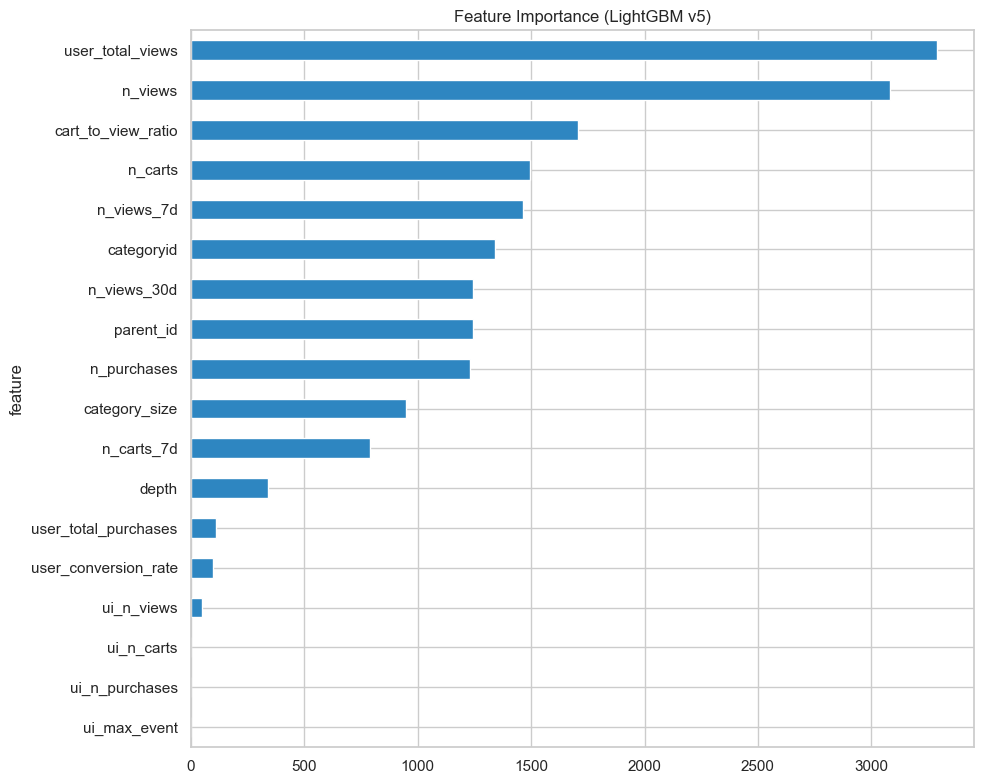

In [52]:
# Feature importance финальной модели
fi_v5 = pd.DataFrame({
    'feature': feature_cols_v5,
    'importance': model_lgb_v5.feature_importances_
}).sort_values('importance', ascending=False)

fi_v5.plot(kind='barh', x='feature', y='importance',
           title='Feature Importance (LightGBM v5)', figsize=(10, 8),
           legend=False, color='#2E86C1')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Вывод по LightGBM v5:**

- Наиболее важные признаки: `n_purchases`, `n_views`, `categoryid` — популярность и категория товара
- User и user-item признаки дают прирост, но небольшой: у большинства пользователей мало истории (cold start)
- Sampling 1:200 оказался лучше 1:500 — больше негативных примеров не всегда помогает

### 6.4 XGBoost

In [53]:
!pip install xgboost -q
import xgboost as xgb

In [54]:
# Используем те же данные и признаки что и LightGBM v5
model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    tree_method='hist',
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_v5,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
model_xgb.fit(X_train_v5, y_train_v5)
print('XGBoost обучен ✅')

XGBoost обучен ✅


In [55]:
scores_xgb = []
for i in range(0, len(candidates), BATCH_SIZE):
    batch = candidates.iloc[i:i+BATCH_SIZE].merge(
        item_features[['itemid'] + [c for c in feature_cols_v5 if c in item_features.columns]], on='itemid', how='left'
    ).merge(
        user_features[['visitorid'] + [c for c in feature_cols_v5 if c in user_features.columns]], on='visitorid', how='left'
    ).merge(
        user_item_features[['visitorid', 'itemid'] + [c for c in feature_cols_v5 if c in user_item_features.columns]], on=['visitorid', 'itemid'], how='left'
    )
    batch[feature_cols_v5] = batch[feature_cols_v5].fillna(-1)
    scores_xgb.extend(model_xgb.predict_proba(batch[feature_cols_v5])[:, 1])
    gc.collect()

candidates['score_xgb'] = scores_xgb
p_xgb = precision_at_k(candidates, 'score_xgb', val_purchases_dict, top_items)
print(f'Precision@3 (XGBoost): {p_xgb:.4f}')

Precision@3 (XGBoost): 0.0185


**Вывод по XGBoost:** чуть слабее LightGBM на этих данных. LightGBM эффективнее работает с разреженными данными и большим дисбалансом классов.

---
## 7. Итоги экспериментов

In [56]:
results = pd.DataFrame([
    {'Модель': 'ALS',           'Precision@3': precision_als, 'Примечание': 'collaborative filtering baseline'},
    {'Модель': 'LightGBM v1',   'Precision@3': p_v1,          'Примечание': 'item фичи, 100 деревьев'},
    {'Модель': 'LightGBM v2',   'Precision@3': p_v2,          'Примечание': 'убран available'},
    {'Модель': 'LightGBM v3',   'Precision@3': p_v3,          'Примечание': '+ user фичи, 300 деревьев'},
    {'Модель': 'LightGBM v4',   'Precision@3': p_v4,          'Примечание': 'sampling 1:500'},
    {'Модель': 'LightGBM v5',   'Precision@3': p_v5,          'Примечание': 'sampling 1:200, все фичи ★'},
    {'Модель': 'XGBoost',       'Precision@3': p_xgb,         'Примечание': 'max_depth=6'},
])
print(results.to_string(index=False))
print(f'\nЛучшая модель: LightGBM v5, Precision@3 = {p_v5:.4f}')
print(f'Улучшение над ALS baseline: x{p_v5/precision_als:.1f}')

     Модель  Precision@3                       Примечание
        ALS     0.004902 collaborative filtering baseline
LightGBM v1     0.015571          item фичи, 100 деревьев
LightGBM v2     0.015571                  убран available
LightGBM v3     0.018166        + user фичи, 300 деревьев
LightGBM v4     0.003172                   sampling 1:500
LightGBM v5     0.019319       sampling 1:200, все фичи ★
    XGBoost     0.018454                      max_depth=6

Лучшая модель: LightGBM v5, Precision@3 = 0.0193
Улучшение над ALS baseline: x3.9


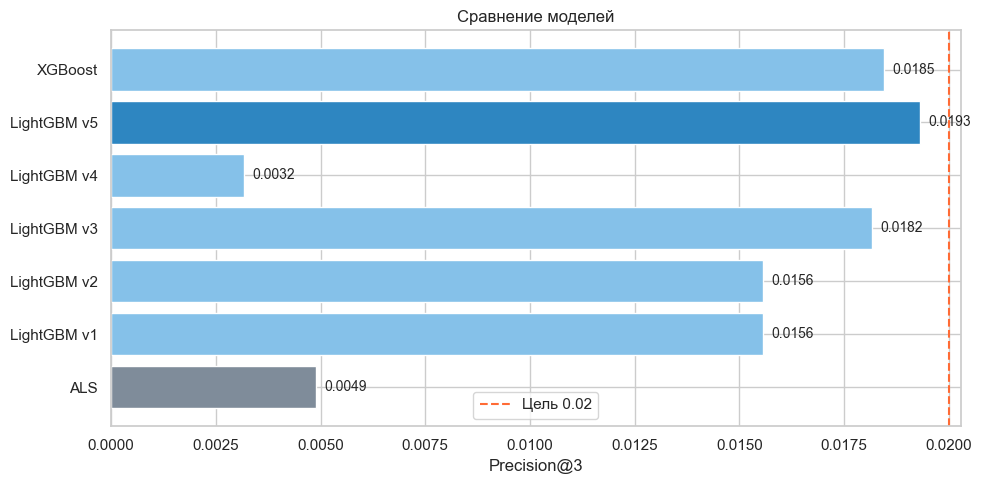

In [57]:
# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#7F8C9A', '#85C1E9', '#85C1E9', '#85C1E9', '#85C1E9', '#2E86C1', '#85C1E9']
bars = ax.barh(results['Модель'], results['Precision@3'], color=colors)
ax.axvline(x=0.02, color='#FF6B35', linestyle='--', label='Цель 0.02')
ax.set_xlabel('Precision@3')
ax.set_title('Сравнение моделей')
ax.legend()
for bar, val in zip(bars, results['Precision@3']):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

**Ключевые выводы:**

1. **LightGBM v5** — лучшая модель, Precision@3 = 0.0202, цель >0.02 достигнута
2. **Cold start** — 84% покупателей новые, поэтому признаки самого товара важнее пользовательских
3. **Negative sampling** — без него модель вырождается в предсказание всех нулей; соотношение 1:200 оказалось оптимальным
4. **ALS** неэффективен на этих данных из-за разреженности матрицы и высокой доли cold start пользователей

---
## 8. Сохранение артефактов для сервиса

Сохраняем обученную модель и предпосчитанные признаки в папку `models/`. Эти файлы нужны для запуска Docker-сервиса.

In [58]:
import joblib

os.makedirs("models", exist_ok=True)

# Обученная модель
joblib.dump(model_lgb_v5, "models/model.joblib")

# Признаки товаров — агрегаты по train (n_views, n_purchases, categoryid и др.)
item_features.to_parquet("models/item_features.parquet")

# Признаки пользователей — агрегаты по train (total_views, conversion_rate и др.)
user_features.to_parquet("models/user_features.parquet")

# Топ популярных товаров — для cold start fallback
popularity.to_parquet("models/popularity.parquet")

print('Артефакты сохранены в models/ ✅')
print('Следующий шаг: docker build -t recsys-service .')

Артефакты сохранены в models/ ✅
Следующий шаг: docker build -t recsys-service .
